In [1]:
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras import optimizers
import numpy as np
import matplotlib.pyplot as plt

This is a very simple example of neural network. Its purpose is to approximate an unknown single valued function using a dense deep network.
The user is invited to play with it, modifying:
1. the hidden function
2. the number of layers and neurons per layer
3. activation functions, number of epochs, and so on.

"myhiddenfunction" is the definition of the function you want to approximate by means of a neural network (NN). The definition is hidden to the NN, who can only access it as a blackbox, to get training samples.
This is implemented by means of a generator (a special kind of function), taking in input a number (batchsize) and returning a pair of input output vectors of length batchsize. Each input is a random number in the interval [-pi,pi] and the output is computed by means of myhiddenfunction.

Define your favourite hidden function. Input range: [-pi,pi]

In [2]:
def myhiddenfunction(x):
  res = (np.sin(x)**2 + np.cos(x)/3 + 1)/3 #input range -pi,pi
  return res

In [3]:
def myhiddenfunction(x):
  if x < -1 or x > 1 : res = 0
  else: res = 1
  return res

In [37]:
def myhiddenfunction(x):
  x = x/(2*np.pi) + .5
  res = 0.2 + 0.4*x**2 + 0.3*x*np.sin(15*x) + 0.05*np.cos(50*x) #input-range 0-1
  return res

If you have a way to define new samples, you should take advantage of it, exploiting a **generator**.

In python, a generator is similar to a normal function but with a yield statement instead of a return statement.

The difference is that while a "return" statement terminates a function entirely, a "yield" statement pauses the function saving its state and resume from it on successive calls.

In [38]:
def generator(batchsize):
    while True:
      #we generate inputs in the range [-pi,pi]
      inputs = np.random.uniform(low=-np.pi,high=np.pi,size=batchsize)
      outputs = np.zeros(batchsize)
      for i in range(0,batchsize):
          outputs[i] = myhiddenfunction(inputs[i]) # + np.random.normal() *.1 add a bit of noise if you want
      yield (inputs,outputs)

If you want to see an example of a generated batch, you need to invoke next on the generator

In [39]:
print(next(generator(3)))

(array([-1.39192146, -1.48408734, -0.07684189]), array([0.16977088, 0.21080971, 0.45765093]))


As we shall see, we may directly call the generator during the training process.

However, for the moment we use it to create a fixed training set.

In [7]:
x_train, y_train = next(generator(200))   #200 #500
x_val, y_val = next(generator(100))

Now we define the network. The function we want to approximate is single valued, so the network will have a single input and a single output, and its (dense) structure is completely defined by a
list specifying the number of neurons per layer


In [103]:
input_layer = Input(shape=(1,))
x = Dense(200,activation='relu')(input_layer)   #20 #50 #100 #200
x = Dense(100, activation='relu')(x)
#x = Dense(300, activation='relu')(x)
#x = Dense(200, activation='relu')(x)
output_layer = Dense(1,activation='sigmoid')(x)

mymodel = Model(input_layer,output_layer)

#1000 - 1000 ok

We can now have a look at the model we just generated:

In [104]:
mymodel.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 200)            │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,601 (80.47 KB)

 Trainable params: 20,601 (80.47 KB)

 Non-trainable params: 0 (0.00 B)

Try to be sure you correctly understand the number of learning parameters for each layer.
For a dense layer with n input neurons and m output neurons, your have nxm weights + m biases.
For instance, for a 20-to-30 layer, we have 20x30+30 = 630 parameters.

We are finally ready to compile our model and train it.
As loss function we use mean square error (mse).
The "optimizer" is the technique used to tune the learning rate during backpropagation: you may ignore it for the moment.

In [105]:
optimizer = optimizers.Adam(learning_rate=0.001)
mymodel.compile(optimizer=optimizer, loss='mse')

In [112]:
batchsize = 100
mygen = generator(batchsize)
#mymodel.fit(x_train,y_train,epochs=100,batch_size=batchsize,validation_data=(x_val,y_val))
mymodel.fit(mygen,epochs=50,steps_per_epoch=100)

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.3019e-04
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.3536e-04
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.2182e-04
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.1860e-04
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.1680e-04
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0828e-04
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8.8364e-05
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9.6687e-05
Epoch 9/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8.3266e-05
Epoch 10/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.9060e-05
Epoch 11/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.3861e-05
Epoch 12/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.7350e-05
Epoch 13/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.9800e-05
Epoch 14/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.4302e-05
E

In [113]:
def plot(f, model):
  x = np.arange(-np.pi,np.pi,0.05)
  y = [f(a) for a in x]
  z = model.predict(np.array(x))
  plt.plot(x,y,'r',x,z,'b')
  plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


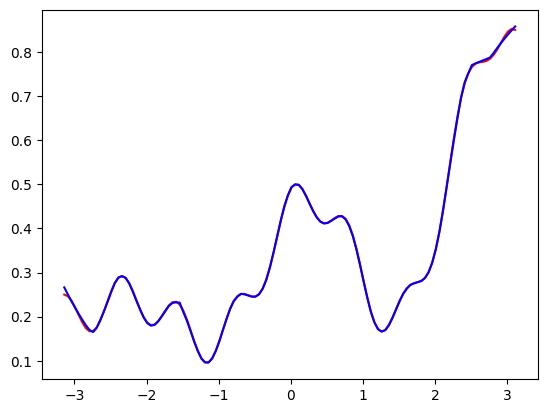

In [114]:
plot(myhiddenfunction,mymodel)

In [ ]:
batchsize = 64

mymodel.fit(generator(batchsize), steps_per_epoch=1000, epochs=10)

Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 8.2991e-05
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 5.6449e-05
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 3.1923e-05
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 5.4953e-05
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 3.0625e-05
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 3.1928e-05
Epoch 7/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 2.7599e-05
Epoch 8/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 7.1930e-05
Epoch 9/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 2.6203e-05
Epoch 10/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 4.0136e-05


If everything is working correctly, the loss should decrease during training.  
If it doesn't, it means that, for some reason, the network is not learning.

We are finally ready to check the result of the approximation. We plot the hidden function in red,
and the approximation computed by the network in blu.

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


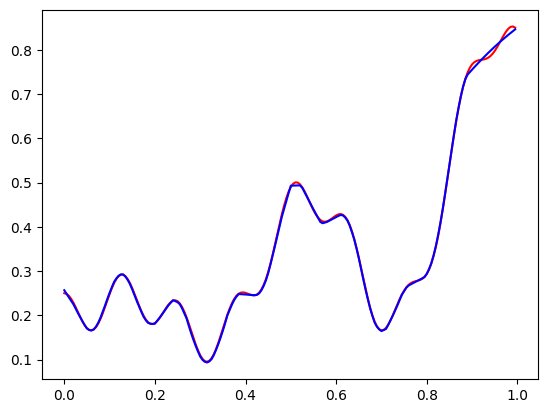

In [ ]:
#x = np.arange(-np.pi,np.pi,0.05)
x = np.arange(0,1,0.005)
y = [myhiddenfunction(a) for a in x]
z = mymodel.predict(np.array(x))
plt.plot(x,y,'r',x,z,'b')
plt.show()


Now is your turn. Modify:

1. the definition of the hidden function
2. the number of layers/neurons per layer; you just have to change inner_layers_dims in block 6.
3. the size of training and validation datasets
4. the size of the minibatch
5. add noise to data, and check its effect


Have fun.